In [3]:
# import statements
import pandas as pd
import requests
import json

import matplotlib.pyplot as plt


## Data Handling + Split

In [55]:
#call data and clean (remove null and duplicate values)
df_old = pd.read_csv('C:/Users/minju/Desktop/DS3000-26Summer/Farmers-Market/datasets/CropRecc.csv')
df_old = df_old.drop_duplicates()

missing_codes = ["--", "", " ", "nan", "NaN", "None"] #account for different possible null combos


for col in df_old.columns:
    if df_old[col].dtype == object:  # only clean string/object columns
        df_old[col] = df_old[col].str.strip().replace(missing_codes, pd.NA)
    else:
        df_old[col] = df_old[col].replace(missing_codes, pd.NA) 

df_old = df_old.dropna()  # remove rows with any null values

print(df_old.columns)
df_old.head()


Index(['CROPS', 'TYPE_OF_CROP', 'SOIL', 'SEASON', 'SOWN', 'HARVESTED',
       'WATER_SOURCE', 'SOIL_PH', 'SOIL_PH_HIGH', 'CROPDURATION',
       'CROPDURATION_MAX', 'TEMP', 'MAX_TEMP', 'WATERREQUIRED',
       'WATERREQUIRED_MAX', 'RELATIVE_HUMIDITY', 'RELATIVE_HUMIDITY_MAX', 'N',
       'N_MAX', 'P', 'P_MAX', 'K', 'K_MAX'],
      dtype='object')


,CROPS,TYPE_OF_CROP,SOIL,SEASON,SOWN,HARVESTED,WATER_SOURCE,SOIL_PH,SOIL_PH_HIGH,CROPDURATION,...,WATERREQUIRED,WATERREQUIRED_MAX,RELATIVE_HUMIDITY,RELATIVE_HUMIDITY_MAX,N,N_MAX,P,P_MAX,K,K_MAX
0,rice,cereals,Alluvial soil,kharif,Jun,Sep,irrigated,7.6,8.0,116.9,...,2462.3,2500,73.8,80,82.4,100,40.7,60,42.2,60
1,rice,cereals,Loamy soil,kharif,Jul,Oct,rainfed,6.2,8.0,117.9,...,1237.5,2500,60.9,80,90.5,100,51.3,60,46.2,60
2,rice,cereals,Clay soil,kharif,Jun,Sep,irrigated,6.7,8.0,117.7,...,1075.1,2500,67.5,80,86.2,100,50.7,60,44.4,60
3,rice,cereals,Alluvial soil,kharif,Jul,Oct,rainfed,6.1,8.0,149.8,...,1549.9,2500,73.6,80,91.3,100,51.3,60,44.5,60
4,rice,cereals,Loamy soil,kharif,Jun,Sep,irrigated,8.0,8.0,131.7,...,1306.4,2500,60.3,80,81.3,100,48.6,60,51.0,60


In [12]:
#check correlation 
correlations = df_old.corr(numeric_only=True)
print(correlations)

                        SOIL_PH  SOIL_PH_HIGH  CROPDURATION  CROPDURATION_MAX  \
SOIL_PH                1.000000      0.664134      0.100256          0.100767   
SOIL_PH_HIGH           0.664134      1.000000      0.199739          0.202836   
CROPDURATION           0.100256      0.199739      1.000000          0.977613   
CROPDURATION_MAX       0.100767      0.202836      0.977613          1.000000   
TEMP                   0.219149      0.272520      0.172977          0.140207   
MAX_TEMP               0.220374      0.282283      0.094633          0.077540   
WATERREQUIRED          0.043510      0.036607      0.307509          0.283561   
WATERREQUIRED_MAX      0.046160      0.074244      0.316633          0.297407   
RELATIVE_HUMIDITY     -0.048196     -0.118704     -0.023659          0.006901   
RELATIVE_HUMIDITY_MAX -0.031097     -0.081447     -0.006653          0.019987   
N                     -0.014683     -0.109038      0.270526          0.304813   
N_MAX                 -0.024

In [57]:
#one-hot encoding to turn categorical value into numerical
#create df_sub and df_sub_drop (clean dataset/create subsets)
#df_sub = df.drop(columns='Crop_Health_Label', axis=1)
# Save all one-hot encoded column names
ohe_cols = [col for col in df_sub.columns 
            if col.startswith(( 'CROPS_','TYPE_OF_CROP_', 'SOIL_', 'SOWN_', 'HARVESTED_', 'WATER_SOURCE_','SEASON'))]

ohe_data = df_sub[ohe_cols].copy()  # save the actual data

# Drop from df
df_sub = df_sub.drop(columns=ohe_cols)

#all one value (not helpful for pred)
columnsToDrop = ['CROPDURATION_MAX', 'MAX_TEMP',
       'WATERREQUIRED_MAX', 'RELATIVE_HUMIDITY_MAX',
       'N_MAX','P_MAX', 'K_MAX']

df_sub_drop = df_sub.drop(columns=columnsToDrop, axis=1)

#print(df_sub_drop.columns)

df_sub_drop.head()
#df_sub.head()


,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
0,116.9,26.9,2462.3,73.8,82.4,40.7,42.2
1,117.9,35.8,1237.5,60.9,90.5,51.3,46.2
2,117.7,34.9,1075.1,67.5,86.2,50.7,44.4
3,149.8,28.3,1549.9,73.6,91.3,51.3,44.5
4,131.7,26.3,1306.4,60.3,81.3,48.6,51.0


In [49]:
df_sub_drop.shape

(57000, 7)

In [66]:
from sklearn.model_selection import train_test_split
#split continuous and binary data at same time, consistent rand state
y_vec = df_old['CROPS'].to_numpy()

X_train_cont, X_test_cont, y_train, y_test = train_test_split(
    df_sub_drop.to_numpy(), y_vec, test_size=0.3, random_state=3000
)
binary_train, binary_test, _, _ = train_test_split(
    ohe_data, y_vec, test_size=0.3, random_state=3000
)

In [67]:
import numpy as np
from sklearn.preprocessing import StandardScaler

#scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cont)
X_test_scaled = scaler.transform(X_test_cont)

#add binary columns back

# df_sub = pd.concat([df_sub, ohe_data], axis=1)

X_train = np.concatenate([X_train_scaled, binary_train.to_numpy()], axis=1)
X_test = np.concatenate([X_test_scaled, binary_test], axis=1)

#add column of y-intercept. ONLY FOR LOG REG!
ones = np.ones((X_train.shape[0], 1), dtype=X_train.dtype)
X_train_reg = np.hstack([ones, X_train])

ones = np.ones((X_test.shape[0], 1), dtype=X_test.dtype)
X_test_reg = np.hstack([ones, X_test])

#pd.DataFrame(X_train_scaled).head()
#pd.DataFrame(X_test_scaled).head()

pd.DataFrame(X_test_reg).head()



,0,1,2,3,4,5,6,7
0,1.0,-0.920322,-0.455600,0.148607,0.323797,-0.142264,0.276985,-0.190717
1,1.0,-0.444273,-0.592171,-1.433299,0.461592,-0.695699,-0.932906,-0.800883
2,1.0,0.031776,-0.216599,0.310502,0.702734,0.351980,0.125749,-0.553911
3,1.0,-0.305033,-0.984815,-0.564345,0.095573,-0.189617,-1.322630,-1.207661
4,1.0,-0.528945,-0.080028,0.338840,0.293654,0.547310,0.486389,0.880706


## KNN Model

In [72]:
from collections import Counter
def knn_cos_with_loop(X_train, y_train, X_test, k):

    y_pred = []
    nearest_neighbors = []

    train_norms = np.linalg.norm(X_train, axis=1, keepdims=True)
    
    X_train_norm = X_train / train_norms
    #i = 0
    for testp in X_test:
        #i += 1
        #print(f'The current iteration is: {i}', end='\r')

        norm_test = testp/np.linalg.norm(testp)
        similarities = norm_test @ X_train_norm.T
        #print(similarities.shape)
            
        neighbor_indices = np.argsort(similarities)[-k:]
        del similarities
        #print(neighbor_indices)
        neighbor_values = y_train[neighbor_indices]
        #print(neighbor_values)

        # Majority vote instead of mean (y_train is categorical)
        most_common = Counter(neighbor_values).most_common(1)[0][0]#among knn, whichever crop label appears most often is the prediction (maj vote)
        y_pred.append(most_common)
        nearest_neighbors.append(neighbor_indices)
    
    return np.array(y_pred), nearest_neighbors

In [107]:
X_train.shape

(51086, 30)

## plot data with ks and model

We are beginning the modeling of k=1
We are beginning the modeling of k=2
We are beginning the modeling of k=3
We are beginning the modeling of k=4
We are beginning the modeling of k=5


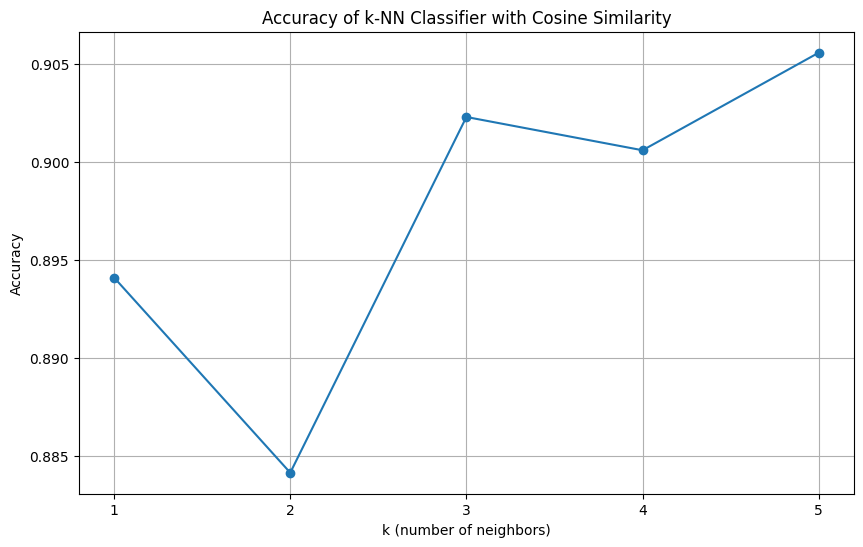

In [74]:
from sklearn.metrics import accuracy_score

#loop through k and print acc
k_values = [1, 2, 3, 4, 5]
accuracy_values = []

for k in k_values:
    print(f'We are beginning the modeling of k={k}')
    y_pred, _ = knn_cos_with_loop(X_train, y_train, X_test, k)
    acc = accuracy_score(y_test, y_pred)
    accuracy_values.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_values, marker='o')
plt.title('Accuracy of k-NN Classifier with Cosine Similarity')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid()
plt.show()

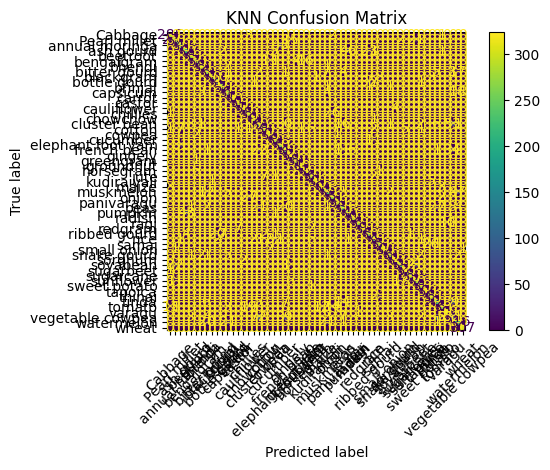

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# get predictions for chosen k
y_pred_knn, _ = knn_cos_with_loop(X_train, y_train, X_test, k=3)

cm_knn = confusion_matrix(y_test, y_pred_knn)

# plain display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=np.unique(y_test))
disp.plot(xticks_rotation=45)
plt.title('KNN Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
#predict new with knn
def predict(new_data: dict, k=3):
    """
    new_data: dictionary of feature names and their values
    e.g:
        data = {
            'N_MIN': 50,
            'P_MIN': 30,
            'K_MIN': 20,
            'TEMPERATURE': 25,
            ...
        }
    """
    # turn inp into df row
    new_df = pd.DataFrame([new_data])
    
    # extract continuous features (same columns as df_sub_drop)
    new_cont = new_df[df_sub_drop.columns].to_numpy()
    
    # scale using the SAME scaler fit on training data
    new_cont_scaled = scaler.transform(new_cont)
    
    # extract OHE features
    new_ohe = new_df[ohe_cols].to_numpy()
    
    # concatenate continuous + binary
    new_X = np.concatenate([new_cont_scaled, new_ohe], axis=1)
    
    # run thru model
    prediction, neighbors = knn_cos_with_loop(X_train, y_train, new_X, k)
    
    print(f'Predicted crop: {prediction[0]}')
    print(f'Nearest neighbor indices: {neighbors[0]}')
    return prediction[0]

## Logistic Regression Model

In [82]:
import numpy as np

In [142]:
#faster logres function
def logistic_regression_loop(X, y, w, alpha=1.0, max_iter=1000):
    """
    A function that runs logistic regression for some maximum number of iterations

    Args:
        X (array): an array of all the predictors where the rows are the observations (includes bias term)
        y (array): an array of all response values (-1 or 1)
        w (array): the initial weight vector
        alpha (float): learning rate (default = 1.0)
        max_iter (int): maximum number of iterations over the dataset (default = 1000)

    Returns:
        w (array): the final weight vector
    """
    w = np.asarray(w, dtype=float).copy() #cast to float to fix dtype error
    n = len(y)

    for _ in range(max_iter): #just run max iter times
        for i in range(n):
            yhat = 1.0 / (1.0 + np.exp(-X[i] @ w))
            w -= alpha * (yhat - y[i]) * X[i]

        # print loss every 100 iterations
        if _ % 100 == 0:
            yhats = 1 / (1 + np.exp(-X @ w)) #current weights on training data to get predicted probabilities
            loss = log_loss(y, yhats) #calculate loss
            print(f"Iter {_}: loss = {loss:.4f}")

    print(f"Algorithm reached max_iter={max_iter}, final w = {w}")
    return w

In [20]:
#X_train_reg, X_test_reg
#print(pd.DataFrame(X_train_reg)).columns

In [143]:
X_train_reg.shape

(51086, 31)

In [144]:
#number of features is 28 +1 (intercept)
weight= np.zeros(X_train_reg.shape[1]) #start from 0s

print(weight)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0.]


In [145]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(max_iter=1000)
sk_model.fit(X_train_reg, y_train)
print("sklearn accuracy:", sk_model.score(X_test_reg, y_test))

sklearn accuracy: 0.49357970560601316


In [146]:
correlations = df.corr(numeric_only=True)['Crop_Health_Label'].sort_values(ascending=False)
print(correlations)

Crop_Health_Label            1.000000
Chlorophyll_Content          0.007143
GPS_Coordinates              0.006882
Temporal_Images              0.005549
Thermal_Images               0.004192
Crop_Growth_Stage            0.003786
Wind_Speed                   0.003189
Canopy_Coverage              0.003053
Rainfall                     0.002636
Bounding_Boxes               0.002064
NDVI                         0.002051
Pest_Hotspots                0.001748
Spatial_Resolution           0.001122
Organic_Matter               0.001011
Leaf_Area_Index              0.000731
Expected_Yield               0.000374
Drainage_Features            0.000314
Crop_Stress_Indicator       -0.000133
Temperature                 -0.000546
Multispectral_Images        -0.000581
High_Resolution_RGB         -0.001060
Field_Boundaries            -0.001180
Water_Flow                  -0.001278
Soil_Moisture               -0.001680
SAVI                        -0.002199
Pest_Damage                 -0.002391
Ground_Truth

In [148]:
modelRun = logistic_regression_loop(X_train_reg, y_train, weight, alpha=0.1, max_iter=5000)
#added more iterations to start bc idk why its not learning; alpha at .1 for larger jumps to detect change


Iter 0: loss = 0.9118


KeyboardInterrupt: 

In [124]:
def predict_logistic(x, w, pred0 = True):
    '''
    This computes the logistic (sigmoid) function, which maps any real number to a probability between 0 and 1.

    x (array): feature vector x (input by user)
    w (array): weights from model

    pred0: pred0=True predicts the probability of class 1. pred0=False gives the complement, closer to 0
    
    returns yhat: 1D array of predicted probabilities, one per observation

    '''
    if pred0 == True:
        yhat = 1/(1 + np.exp(np.dot(x, w)))
    else:
        yhat = np.exp(np.dot(x, w))/(1 + np.exp(np.dot(x, w)))
    return yhat

yhati = np.apply_along_axis(predict_logistic, 1, X_test_reg, pred0 = False, w=modelRun)

print(yhati.round(3)) #predicted probabilities
print(y_test) #actual labels

[0.613 0.414 0.586 ... 0.524 0.512 0.507]
[0 0 0 ... 0 1 1]


In [125]:
from collections import Counter

Counter(y_test)

Counter({np.int64(1): 6394, np.int64(0): 6378})

In [126]:
yhat_thresh = yhati.round(0)

Counter(yhat_thresh)

Counter({np.float64(1.0): 7783, np.float64(0.0): 4989})

In [127]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, yhat_thresh)
cm

array([[2429, 3949],
       [2560, 3834]])

In [128]:
# True Negative Rate (Correctly predicted Unhealthy Crops)
print(f'True Negative Rate is: {cm[0,0]/sum(cm[0,:])}')
# False Positive Rage
print(f'False Positive Rate is: {1-cm[0,0]/sum(cm[0,:])}')
# True Positive Rate/Rate (correctly predicted Healthy Crops)
print(f'True Positive Rate is: {cm[1,1]/sum(cm[1,:])}')
# False Negaive Rate
print(f'False Negative Rate is: {1-cm[1,1]/sum(cm[1,:])}')
# Precision
print(f'The Precision is: {cm[1,1]/(cm[0,0] + cm[1,1])}')
# F1-Score
precision = cm[1,1]/(cm[0,0] + cm[1,1])
recall = cm[1,1]/sum(cm[1,:])
print(f'The F1-Score is: {2*(precision*recall)/(precision + recall)}')
print(f'The accuracy of the model is: {(cm[0,0] + cm[1,1])/len(y_test)}')

True Negative Rate is: 0.3808403888366259
False Positive Rate is: 0.6191596111633741
True Positive Rate is: 0.5996246481076009
False Negative Rate is: 0.40037535189239915
The Precision is: 0.6121666932779818
The F1-Score is: 0.6058307655842615
The accuracy of the model is: 0.49036955840901975


iter 1-before cut to 50/50: (after one hot encode, got reduce from 70s to 69%)
- True Negative Rate is: 0.009793081661664824
- False Positive Rate is: 0.9902069183383352
- True Positive Rate is: 0.9920650931342883
- False Negative Rate is: 0.007934906865711744
- The Precision is: 0.9958150523118461
- The F1-Score is: 0.9939365357407531
- The accuracy of the model is: 0.6987548344495802

In [63]:
np.mean((y_test - yhat_thresh) ** 2)

np.float64(0.29525516460711254)

## Log Loss Comparison of both models

In [113]:
# log loss for logistic regression
#np.mean(-y_test*np.log(yhati) - (1-y_test)*np.log(1-yhati))
logloss = log_loss(y_test, yhati)

ValueError: Found input variables with inconsistent numbers of samples: [21202, 12772]